# Batch experiment plots

This notebook reads the newest `experiment-runs-*.csv` and `experiment-aggregates-*.csv` in `cmd/batch_sim/outputs`. Generate a fresh pair with:

```sh
go run ./cmd/batch_sim -output-dir cmd/batch_sim/outputs
```

Set `RUNS_CSV` or `AGGREGATES_CSV` in the next cell to inspect a specific historical export. The plots below render every workload, policy, and evaluator combination found in the selected CSVs.

In [42]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("dark_background")
plt.rcParams.update(
    {
        "figure.facecolor": "#0B1020",
        "axes.facecolor": "#131B2E",
        "axes.edgecolor": "#94A3B8",
        "axes.labelcolor": "#E2E8F0",
        "text.color": "#F8FAFC",
        "xtick.color": "#CBD5E1",
        "ytick.color": "#CBD5E1",
        "grid.color": "#334155",
        "grid.alpha": 0.55,
        "axes.grid": True,
        "axes.titleweight": "bold",
        "figure.titleweight": "bold",
    }
)
pd.set_option("display.max_rows", 100)

# Leave these as None to use the newest CSVs in cmd/batch_sim/outputs.
RUNS_CSV = None
AGGREGATES_CSV = None


def repository_root(start=Path.cwd()):
    for directory in (start, *start.parents):
        if (directory / "cmd" / "batch_sim").is_dir():
            return directory
    raise FileNotFoundError("Could not find the repository root (expected cmd/batch_sim).")


ROOT = repository_root()
OUTPUTS_DIR = ROOT / "cmd" / "batch_sim" / "outputs"


def newest_csv(prefix):
    candidates = list(OUTPUTS_DIR.glob(f"{prefix}-*.csv"))
    if not candidates:
        raise FileNotFoundError(f"No {prefix}-*.csv found in {OUTPUTS_DIR}")
    return max(candidates, key=lambda path: path.stat().st_mtime)


runs_path = Path(RUNS_CSV) if RUNS_CSV else newest_csv("experiment-runs")
aggregates_path = (
    Path(AGGREGATES_CSV) if AGGREGATES_CSV else newest_csv("experiment-aggregates")
)
runs = pd.read_csv(runs_path)
aggregates = pd.read_csv(aggregates_path)

required_runs = {"workload", "policy", "seed", "evaluation", "value"}
required_aggregates = {"workload", "policy", "evaluation", "mean"}
if missing := required_runs - set(runs.columns):
    raise ValueError(f"Run CSV is missing columns: {sorted(missing)}")
if missing := required_aggregates - set(aggregates.columns):
    raise ValueError(f"Aggregate CSV is missing columns: {sorted(missing)}")

runs["seed"] = pd.to_numeric(runs["seed"])
runs["value"] = pd.to_numeric(runs["value"])
aggregates["mean"] = pd.to_numeric(aggregates["mean"])

print(f"Runs:       {runs_path}")
print(f"Aggregates: {aggregates_path}")
print(f"Workloads:  {', '.join(sorted(aggregates.workload.unique()))}")
print(f"Policies:   {', '.join(sorted(aggregates.policy.unique()))}")
print(f"Evaluators: {', '.join(sorted(aggregates.evaluation.unique()))}")

workloads = sorted(aggregates.workload.unique())
policies = sorted(aggregates.policy.unique())
evaluators = sorted(aggregates.evaluation.unique())
cool_palette = ["#60A5FA", "#A78BFA", "#F472B6", "#22D3EE", "#818CF8"]
evaluator_colors = {
    evaluator_name: cool_palette[index % len(cool_palette)]
    for index, evaluator_name in enumerate(evaluators)
}

# Compute one stable score range per evaluator from both raw and aggregate values.
# The small padding prevents a bar or point from touching the edge of a subplot.
score_values = pd.concat(
    [
        aggregates[["evaluation", "mean"]].rename(columns={"mean": "score"}),
        runs[["evaluation", "value"]].rename(columns={"value": "score"}),
    ],
    ignore_index=True,
)


def padded_limits(values):
    low, high = values.min(), values.max()
    padding = max((high - low) * 0.05, 0.01)
    return low - padding, high + padding


score_limits = {
    evaluator_name: padded_limits(group["score"])
    for evaluator_name, group in score_values.groupby("evaluation")
}
global_score_limits = padded_limits(score_values["score"])

Runs:       /Users/Natha/source/repos/projects/packing_simulator/cmd/batch_sim/outputs/experiment-runs-20260907T194009.529895000Z.csv
Aggregates: /Users/Natha/source/repos/projects/packing_simulator/cmd/batch_sim/outputs/experiment-aggregates-20260907T194009.529917000Z.csv
Workloads:  flat-boxes, mostly-large, mostly-small
Policies:   bottom-left, largest-area-bottom-left
Evaluators: Container fragmentation, Container utilization, Future fit probability


In [43]:
print(
    f"Plotting {len(workloads)} workloads × {len(policies)} policies × "
    f"{len(evaluators)} evaluators = "
    f"{len(workloads) * len(policies) * len(evaluators)} combinations."
)

Plotting 3 workloads × 2 policies × 3 evaluators = 18 combinations.


## 1. Aggregate score for every policy across evaluators

Each subplot is one workload/policy pair; its bars are the aggregate scores for every evaluator. All panels use a common score range, which makes the same evaluator directly comparable across any workload/policy pair.

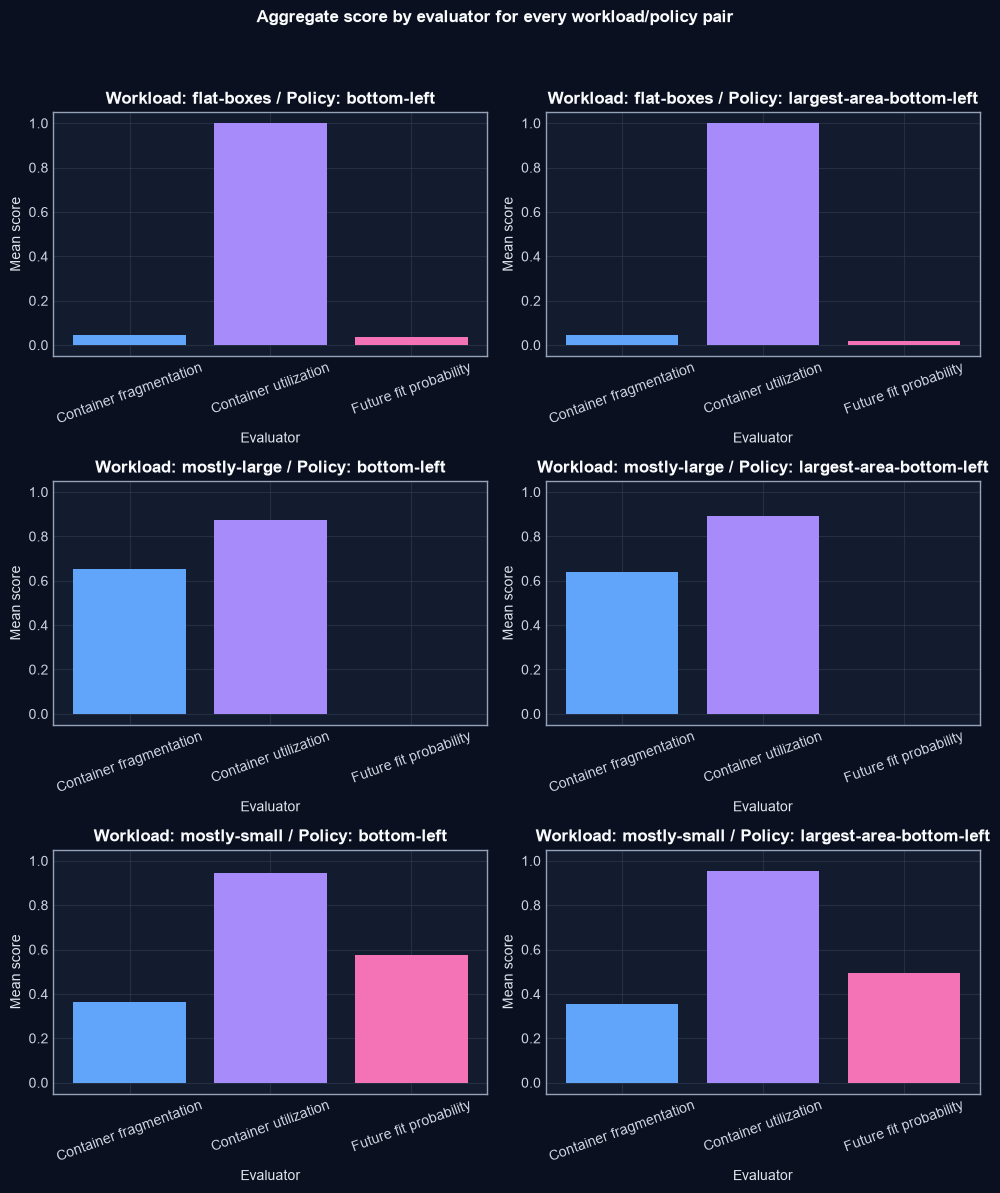

In [44]:
fig, axes = plt.subplots(
    len(workloads), len(policies), squeeze=False, figsize=(5 * len(policies), 4 * len(workloads))
)
for row, workload_name in enumerate(workloads):
    for col, policy_name in enumerate(policies):
        ax = axes[row, col]
        scores = aggregates[
            (aggregates["workload"] == workload_name)
            & (aggregates["policy"] == policy_name)
        ].set_index("evaluation")["mean"].reindex(evaluators)
        ax.bar(
            evaluators,
            scores,
            color=[evaluator_colors[evaluator_name] for evaluator_name in evaluators],
        )
        ax.set(
            title=f"Workload: {workload_name} / Policy: {policy_name}",
            xlabel="Evaluator",
            ylabel="Mean score",
            ylim=global_score_limits,
        )
        ax.tick_params(axis="x", rotation=20)
fig.suptitle("Aggregate score by evaluator for every workload/policy pair", y=0.99)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## 2. Aggregate score for every evaluator across policies

Each subplot is one evaluator. Within it, bars are grouped by workload and then policy; color, labels, and divider lines mark the workload partitions. Every evaluator retains its standardized score range.

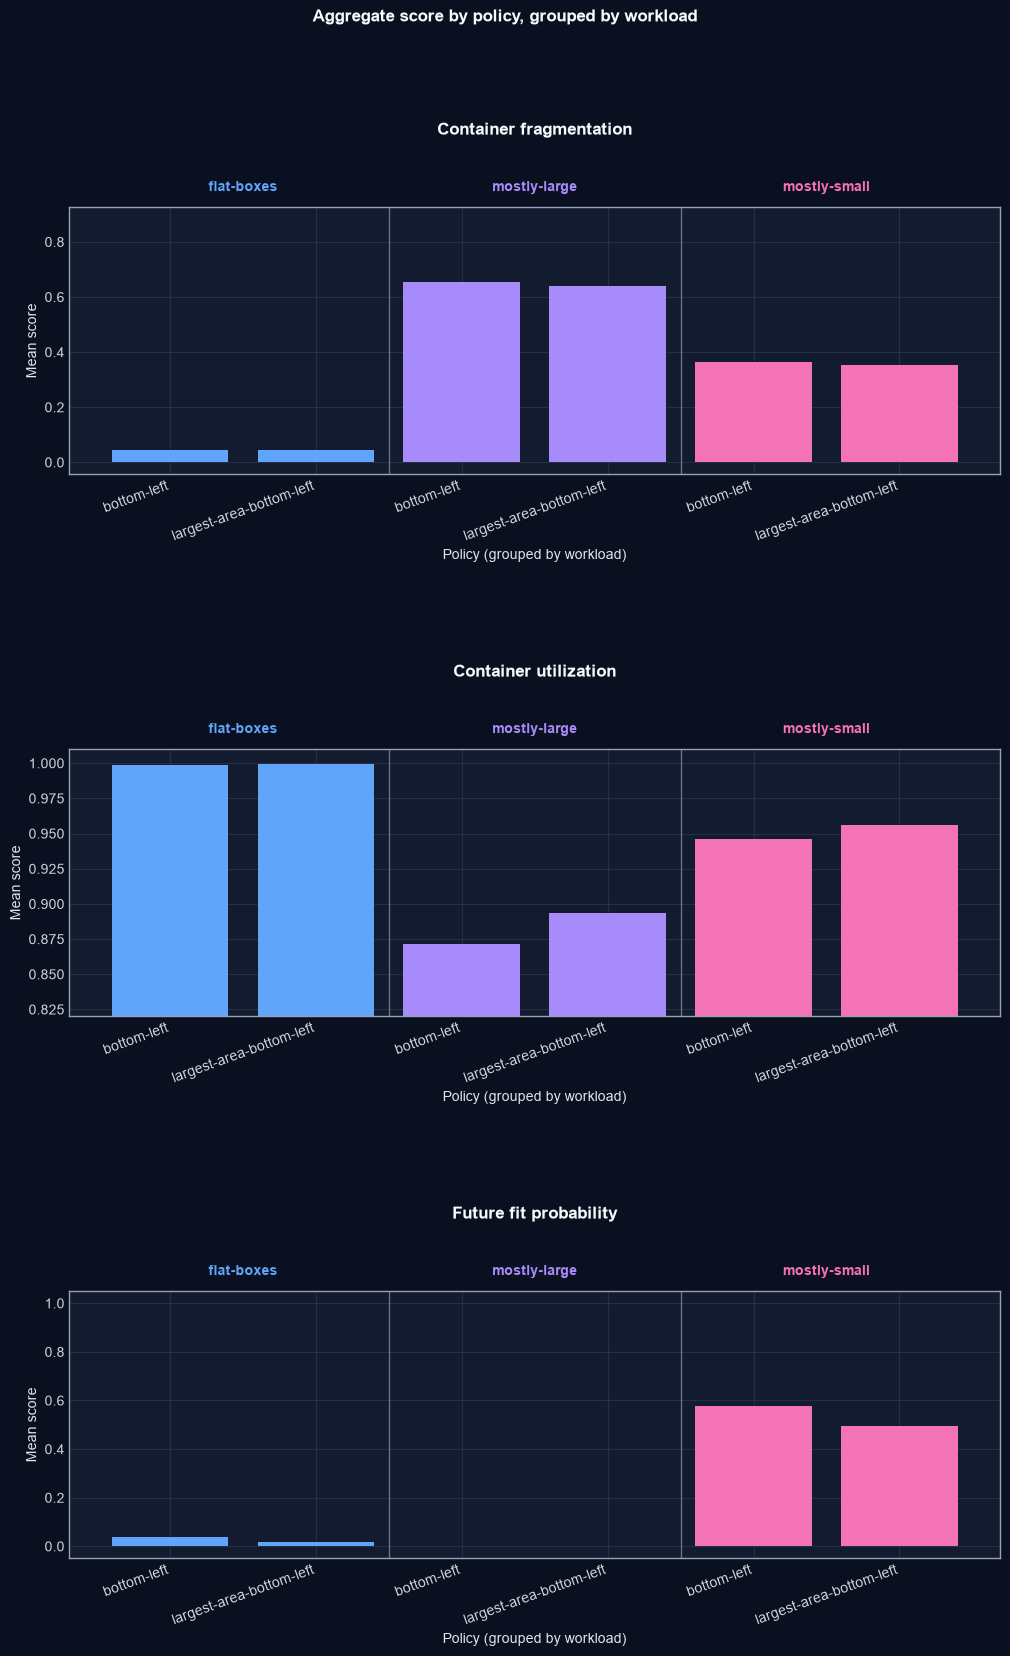

In [45]:
pairs = [(workload_name, policy_name) for workload_name in workloads for policy_name in policies]
positions = list(range(len(pairs)))
workload_colors = {
    workload_name: cool_palette[index % len(cool_palette)]
    for index, workload_name in enumerate(workloads)
}

fig, axes = plt.subplots(
    len(evaluators),
    1,
    squeeze=False,
    figsize=(max(10, 1.7 * len(pairs)), 5.2 * len(evaluators) + 1),
)
for col, evaluator_name in enumerate(evaluators):
    ax = axes[col, 0]
    scores = (
        aggregates[aggregates["evaluation"] == evaluator_name]
        .set_index(["workload", "policy"])["mean"]
        .reindex(pairs)
    )
    ax.bar(
        positions,
        scores,
        color=[workload_colors[workload_name] for workload_name, _ in pairs],
    )
    for workload_index, workload_name in enumerate(workloads):
        first = workload_index * len(policies)
        last = first + len(policies) - 1
        ax.text(
            (first + last) / 2,
            1.06,
            workload_name,
            color=workload_colors[workload_name],
            fontweight="bold",
            ha="center",
            transform=ax.get_xaxis_transform(),
        )
        if workload_index:
            ax.axvline(first - 0.5, color="#94A3B8", linewidth=1, alpha=0.65)
    ax.set(
        xlabel="Policy (grouped by workload)",
        ylabel="Mean score",
        ylim=score_limits[evaluator_name],
    )
    ax.set_title(evaluator_name, y=1.24)
    ax.set_xticks(positions, [policy_name for _, policy_name in pairs], rotation=20, ha="right")
fig.suptitle("Aggregate score by policy, grouped by workload", y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.97), h_pad=5.5)
plt.show()

## 3. Per-seed score for every workload/policy/evaluator combination

Each row is a workload/policy pair and each column is an evaluator. Every panel in an evaluator column uses the same score range.

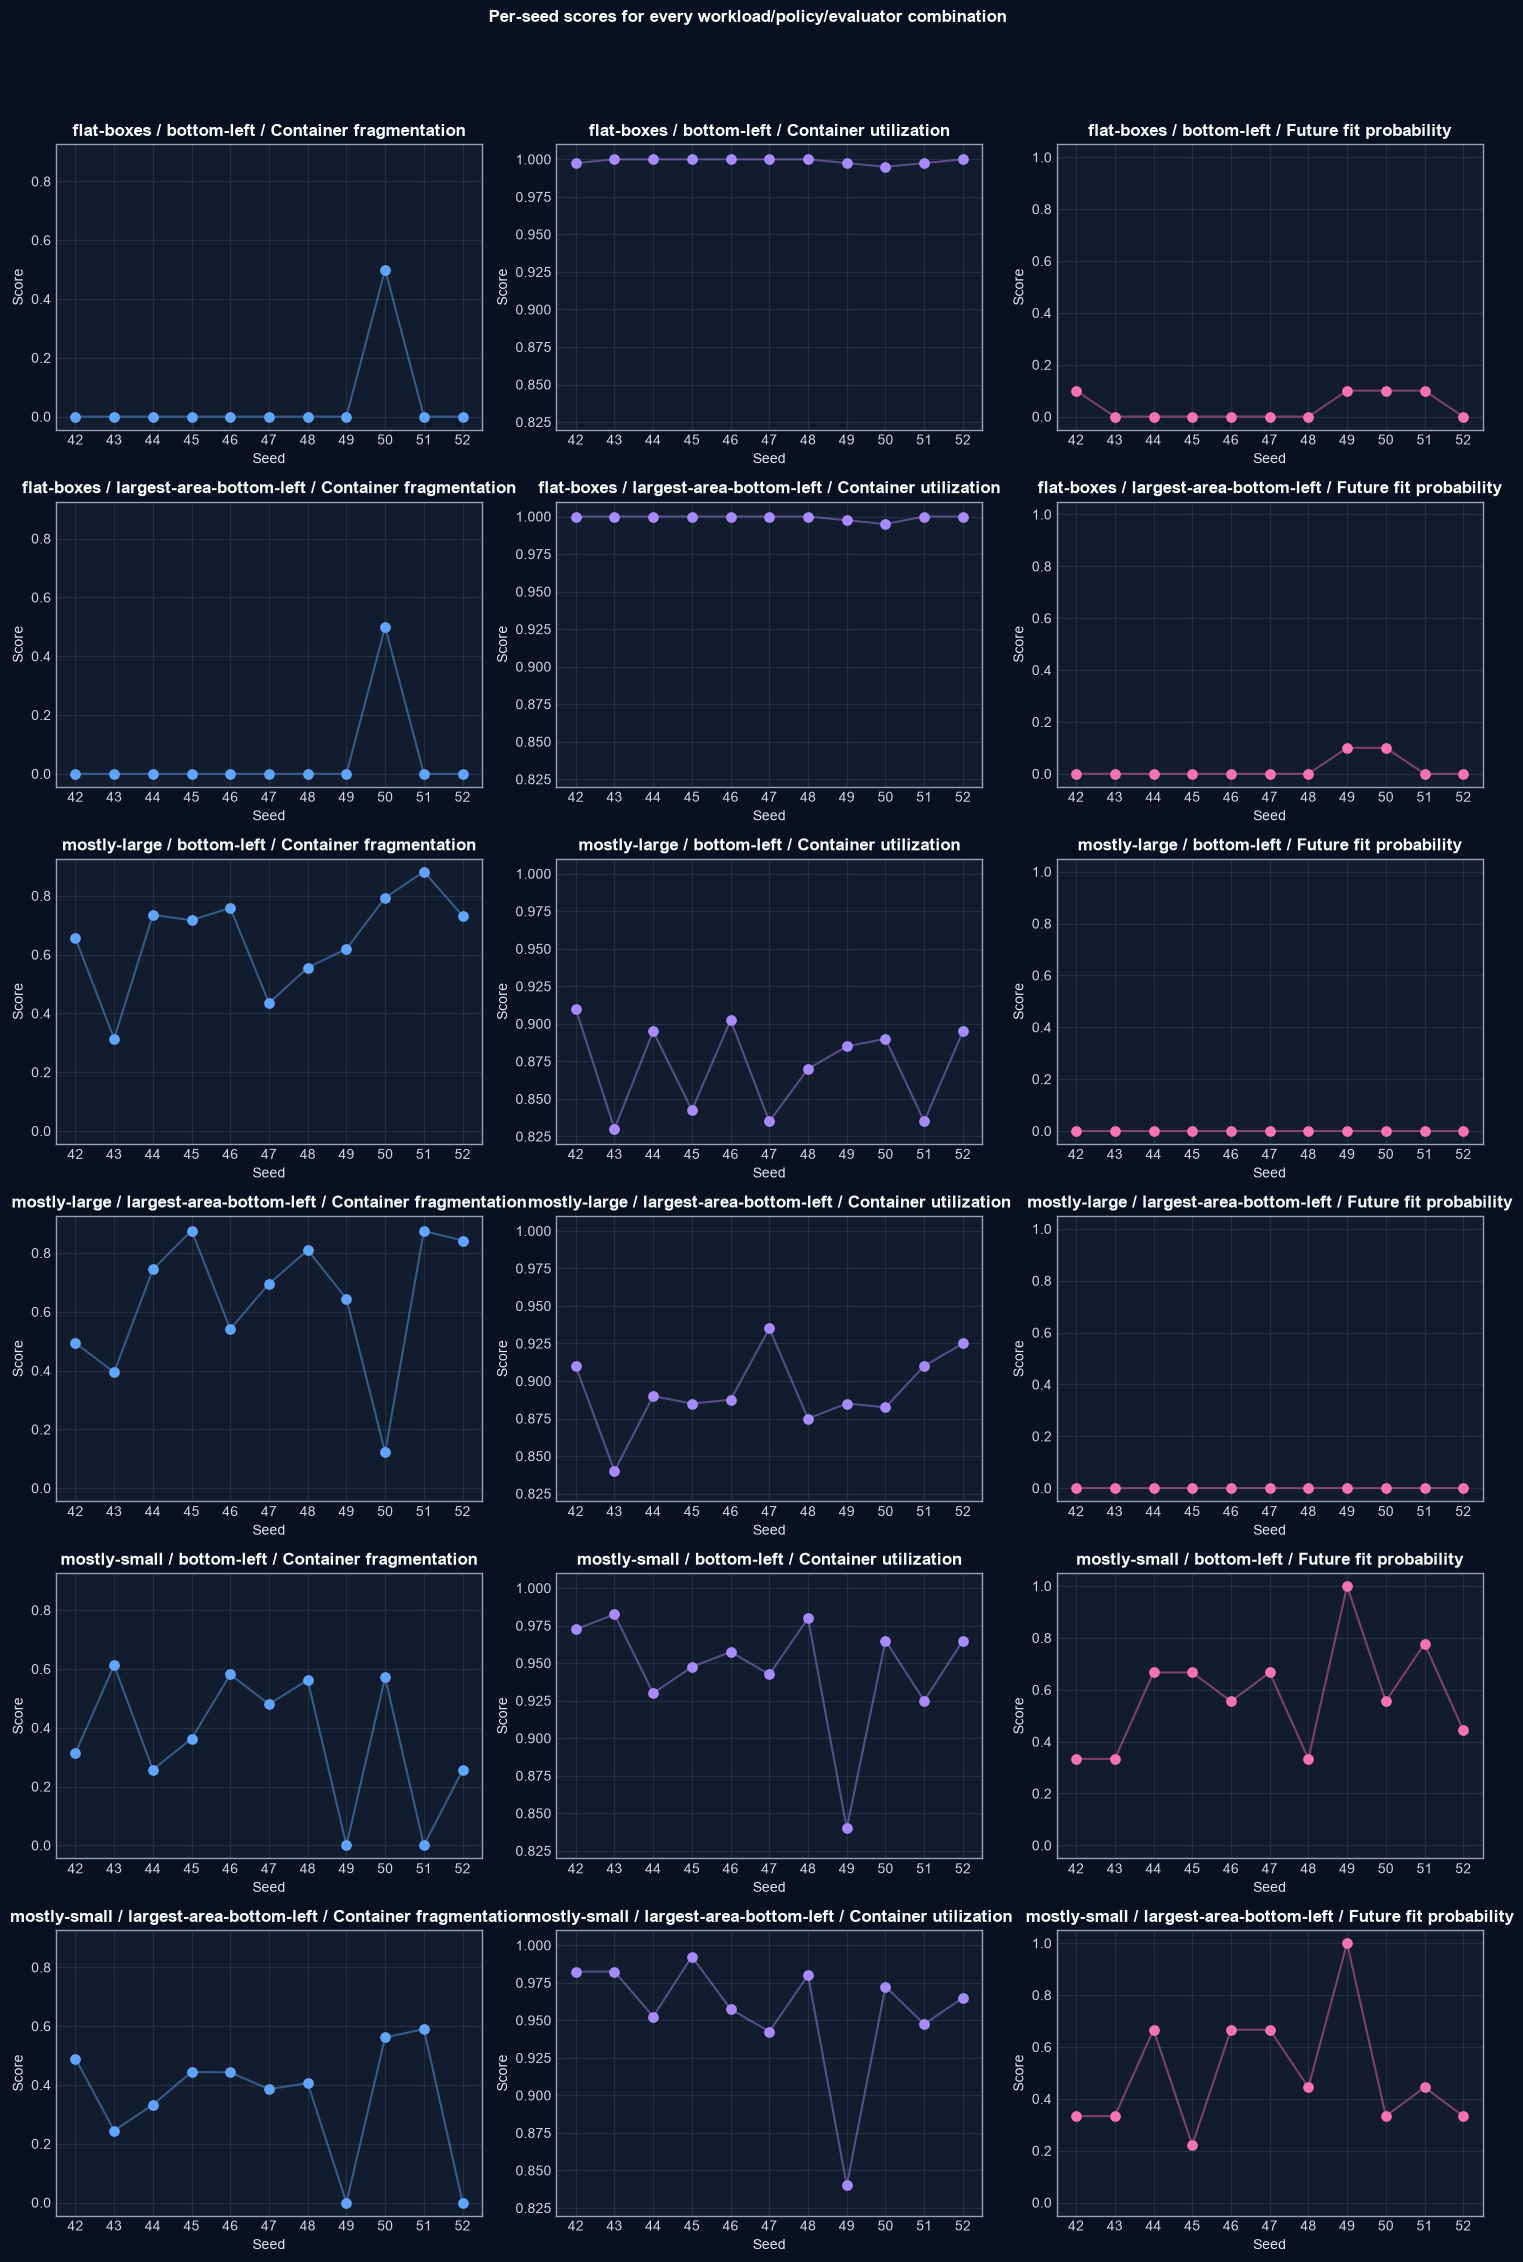

In [46]:
row_pairs = [(workload_name, policy_name) for workload_name in workloads for policy_name in policies]
fig, axes = plt.subplots(
    len(row_pairs), len(evaluators), squeeze=False, figsize=(5 * len(evaluators), 3.8 * len(row_pairs))
)
for row, (workload_name, policy_name) in enumerate(row_pairs):
    for col, evaluator_name in enumerate(evaluators):
        ax = axes[row, col]
        seed_scores = runs[
            (runs["workload"] == workload_name)
            & (runs["policy"] == policy_name)
            & (runs["evaluation"] == evaluator_name)
        ].sort_values("seed")
        if seed_scores.empty:
            ax.set_axis_off()
            continue
        color = evaluator_colors[evaluator_name]
        ax.scatter(seed_scores["seed"], seed_scores["value"], s=45, color=color, zorder=3)
        ax.plot(seed_scores["seed"], seed_scores["value"], color=color, alpha=0.45)
        ax.set(
            title=f"{workload_name} / {policy_name} / {evaluator_name}",
            xlabel="Seed",
            ylabel="Score",
            ylim=score_limits[evaluator_name],
        )
        ax.set_xticks(seed_scores["seed"])
fig.suptitle("Per-seed scores for every workload/policy/evaluator combination", y=0.99)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()